# SPARK: Shopper Patterns and Analytics Research Kit

## Project Overview

Welcome to the **Shopper Patterns and Analytics Research Kit (SPARK)** — a comprehensive data mining project focused on analyzing online shopping behavior and predicting purchasing intentions. This project leverages machine learning classification models and association rule mining to uncover valuable insights from e-commerce session data.

**Domain:** E-commerce and Online Consumer Behavior

**Objective:** Predict whether a website visitor will generate revenue during their session and discover patterns in shopping behavior that influence purchasing decisions.

## Data Mining Task Definition

This project addresses two primary data mining tasks:

### 1. Classification Task
Predict whether a visitor will generate revenue (make a purchase) during their online shopping session. This binary classification problem uses behavioral metrics such as page visits, duration, bounce rates, and traffic sources to make predictions.

**Models Used:**
- Logistic Regression
- Decision Tree Classifier

### 2. Association Rule Mining
Discover interesting patterns and relationships between different shopping behaviors and session characteristics. This unsupervised learning approach helps identify which combinations of behaviors are frequently associated with successful purchases.

## Overall Pipeline Overview

The SPARK project follows a systematic data mining workflow:

**Step 1: Dataset Acquisition**
- Load the Online Shoppers Purchasing Intention Dataset from UCI Repository
- Inspect basic dataset properties and structure

**Step 2: Data Preprocessing**
- Perform exploratory data analysis (EDA)
- Handle missing values and outliers
- Encode categorical variables
- Scale/normalize numerical features

**Step 3: Data Mining - Classification**
- Split data into training and testing sets
- Train Logistic Regression model
- Train Decision Tree model
- Generate predictions

**Step 4: Data Mining - Association Rule Mining**
- Transform data into transactional format
- Generate frequent itemsets
- Extract association rules with support, confidence, and lift metrics

**Step 5: Evaluation**
- Calculate performance metrics (accuracy, precision, recall, F1-score)
- Compare model performances
- Visualize results

**Step 6: Results and Discussion**
- Summarize findings from classification
- Analyze discovered association rules
- Discuss implications and insights

**Step 7: Application Development**
- Present SPARK application concept and architecture

---

# Environment Setup

## Required Libraries

Before beginning the analysis, we need to install and import all necessary libraries for data processing, machine learning, and visualization.

### Install Required Packages

Run this cell to install all required packages. If running locally, you may need to uncomment and run the installation commands.

In [1]:
# Uncomment and run if packages are not installed
!pip install pandas numpy matplotlib seaborn scikit-learn mlxtend plotly streamlit

# For Google Colab users, uncomment the following:
!pip install -q pandas numpy matplotlib seaborn scikit-learn mlxtend plotly

print("Package installation complete!")

Package installation complete!


### Import Libraries

Import all necessary libraries for data manipulation, visualization, machine learning, and association rule mining.

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Model persistence
import pickle
import joblib

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")

All libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5
Scikit-learn version: 1.7.2


---

# 1. Dataset

## Dataset Source and Reference

**Dataset Name:** Online Shoppers Purchasing Intention Dataset

**Source:** UCI Machine Learning Repository

**Link:** [https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

**Original Paper:**
Sakar, C.O., Polat, S.O., Katircioglu, M. et al. (2019). Real-time prediction of online shoppers' purchasing intention using multilayer perceptron and LSTM recurrent neural networks. *Neural Computing & Applications*, 31, 6893–6908.

**Domain:** E-commerce and Online Consumer Behavior

**Purpose:** This dataset enables the study of purchasing intention prediction, which is an important application in data mining and customer analytics.

### Data Collection Process

The records in this dataset were collected from real-world e-commerce websites using **Google Analytics tracking mechanisms**. Key aspects of the data collection process:

- **Session-Level Recording:** User interactions with the website are recorded at the session level, where each session represents a single visit by a unique user.

- **Temporal Coverage:** Data was collected over a **one-year period** to capture seasonal variations and different shopping patterns.

- **Quality Assurance:** Each record represents a unique user session to ensure data quality and reduce bias. This approach minimizes the influence of repeated visits from the same user and ensures that no single user dominates the dataset.

- **Target Derivation:** The target class (Revenue) is derived from the session's outcome, indicating whether the session resulted in a completed purchase.

## 1.1 Load Dataset

Let's load the Online Shoppers Purchasing Intention dataset.

In [3]:
# Load the dataset
# Read the CSV file into a pandas DataFrame
df = pd.read_csv('online_shoppers_intention.csv')

# Display the first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1.2 Dataset Shape and Basic Information

Now let's examine the structure and basic properties of the dataset.

In [4]:
# Display dataset shape (rows and columns)
print("Dataset Information:")
print("=" * 60)
df.info()
print()

# Display basic dataset information
print("Summary Statistics:")
print("=" * 60)
print(df.describe())
print()

# Display summary statistics
print("Missing Values Check:")
print("=" * 60)
missing_values = df.isnull().sum()
print(missing_values)
print()

# Check for missing values
if missing_values.sum() > 0:
    print("Columns with missing values:")
    print(missing_values[missing_values > 0])
else:
    print("✓ No missing values found in the dataset!")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

## 1.3 Dataset Volume Summary

The Online Shoppers Purchasing Intention Dataset contains:

- **Number of Records (Rows):** 12,330 unique user sessions
- **Number of Features (Columns):** 18 attributes
- **Feature Types:** 10 numerical attributes and 8 categorical attributes
- **Target Variable:** Revenue (binary: True/False)

## 1.4 Attribute Grouping and Description

The 18 attributes in this dataset can be organized into the following groups:

### 1. Administrative-Related Attributes
- **Administrative:** Number of administrative pages visited
- **Administrative_Duration:** Total time spent on administrative pages (in seconds)

### 2. Informational-Related Attributes
- **Informational:** Number of informational pages visited
- **Informational_Duration:** Total time spent on informational pages (in seconds)

### 3. Product-Related Attributes
- **ProductRelated:** Number of product-related pages visited
- **ProductRelated_Duration:** Total time spent on product-related pages (in seconds)

### 4. Session and Traffic-Related Attributes
- **BounceRates:** Average bounce rate of pages visited (percentage of visitors who leave after viewing only one page)
- **ExitRates:** Average exit rate of pages visited (percentage of pageviews that were the last in the session)
- **PageValues:** Average page value of pages visited (average value for a page that a user visited before completing an e-commerce transaction)
- **SpecialDay:** Closeness of the site visiting time to a special day (e.g., Valentine's Day, Mother's Day)

### 5. Visitor and Temporal Attributes
- **OperatingSystems:** Operating system used by the visitor
- **Browser:** Browser used by the visitor
- **Region:** Geographic region of the visitor
- **TrafficType:** Traffic source that brought the visitor to the website
- **VisitorType:** Type of visitor (Returning_Visitor, New_Visitor, Other)
- **Weekend:** Boolean indicating if the session occurred on a weekend

### 6. Target Attribute
- **Revenue:** Boolean indicating whether the session resulted in a purchase (True = purchase made, False = no purchase)

---

# 2. Data Preprocessing

## Purpose of Data Preprocessing

Data preprocessing is a critical step in the data mining pipeline. It ensures that the data is clean, consistent, and in a suitable format for machine learning algorithms. The main objectives of preprocessing include:

- **Data Quality Improvement:** Identify and handle missing values, outliers, and inconsistencies
- **Feature Understanding:** Perform exploratory data analysis (EDA) to understand feature distributions and relationships
- **Data Transformation:** Convert categorical variables into numerical format for model compatibility
- **Feature Scaling:** Normalize or standardize numerical features to ensure fair contribution to model training
- **Bias Reduction:** Balance the dataset if needed to prevent model bias toward majority classes

Proper preprocessing significantly improves model performance and generalization capability.

## 2.1 Initial Data Inspection

Let's begin by inspecting the data for any quality issues such as duplicates, missing values, and data type inconsistencies.

In [5]:
print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

# Check for duplicate rows
print("\n DUPLICATE ROWS CHECK")
print("-" * 70)
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
print(f"Percentage of duplicates: {(num_duplicates/len(df))*100:.2f}%")

if num_duplicates > 0:
    print(f"\nRemoving {num_duplicates} duplicate rows...")
    df_clean = df.drop_duplicates()
    print(f"Dataset shape before: {df.shape}")
    print(f"Dataset shape after: {df_clean.shape}")
    print("Duplicates removed")

    df = df_clean
else:
    print("No duplicate rows found")

# Verify data types of all columns
print("\n DATA TYPES VERIFICATION")
print("-" * 70)
print(df.dtypes)
print("\nData type summary:")
print(f"  - Integer columns: {(df.dtypes == 'int64').sum()}")
print(f"  - Float columns: {(df.dtypes == 'float64').sum()}")
print(f"  - Object (categorical) columns: {(df.dtypes == 'object').sum()}")
print(f"  - Boolean columns: {(df.dtypes == 'bool').sum()}")

# Check for data quality issues
print("=" * 70)
print("DATA QUALITY ISSUES")
print("=" * 70)

# Negative values check
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
rate_cols = ['BounceRates', 'ExitRates', 'PageValues']

neg_durations = sum((df[col] < 0).sum() for col in duration_cols)
neg_rates = sum((df[col] < 0).sum() for col in rate_cols)

print(f"Negative durations: {neg_durations}")
print(f"Negative rates: {neg_rates}")

# Rate ranges
print(f"\nBounceRates range: [{df['BounceRates'].min():.3f}, {df['BounceRates'].max():.3f}]")
print(f"ExitRates range: [{df['ExitRates'].min():.3f}, {df['ExitRates'].max():.3f}]")

# Categorical variables
print(f"\nMonth values: {df['Month'].nunique()} unique - {df['Month'].value_counts().head(3).to_dict()}")
print(f"VisitorType: {df['VisitorType'].value_counts().to_dict()}")

# Inconsistent rows (pages but no duration)
inconsistent = sum(((df[col] > 0) & (df[f'{col}_Duration'] == 0)).sum()
                   for col in ['Administrative', 'Informational', 'ProductRelated'])
print(f"\nRows with pages but zero duration: {inconsistent}")

# Target variable distribution
revenue_pct = df['Revenue'].sum() / len(df) * 100
print(f"\nRevenue (Purchase) rate: {revenue_pct:.2f}%")
if revenue_pct < 10:
    print("Imbalanced dataset")

print("\n" + "=" * 60)

DATA QUALITY CHECKS

 DUPLICATE ROWS CHECK
----------------------------------------------------------------------
Number of duplicate rows: 125
Percentage of duplicates: 1.01%

Removing 125 duplicate rows...
Dataset shape before: (12330, 18)
Dataset shape after: (12205, 18)
Duplicates removed

 DATA TYPES VERIFICATION
----------------------------------------------------------------------
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue       

## 2.2 Target Variable Distribution Analysis

Understanding the distribution of the target variable (Revenue) is crucial for assessing class balance and potential model bias.

TARGET VARIABLE ANALYSIS - REVENUE

Revenue Value Counts:
Revenue
False    10297
True      1908
Name: count, dtype: int64

Percentage Distribution:
Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


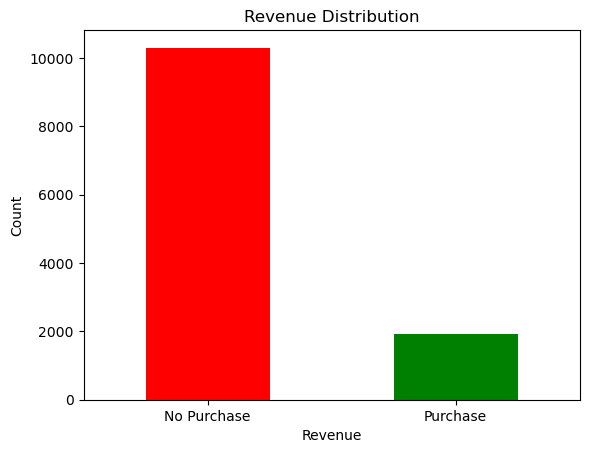


Class Balance Ratio: 5.4:1


In [6]:
# Analyze target variable distribution
print("=" * 60)
print("TARGET VARIABLE ANALYSIS - REVENUE")
print("=" * 60)

print("\nRevenue Value Counts:")
revenue_counts = df['Revenue'].value_counts()
print(revenue_counts)

# Calculate percentage distribution
print("\nPercentage Distribution:")
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100
print(revenue_pct)

# Visualize target variable distribution
df['Revenue'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Purchase', 'Purchase'], rotation=0)
plt.show()

# Display class balance ratio
false_count = df['Revenue'].value_counts()[False]
true_count = df['Revenue'].value_counts()[True]
print(f"\nClass Balance Ratio: {false_count/true_count:.1f}:1")

## 2.3 Numerical Feature Exploratory Data Analysis

Let's explore the statistical properties and distributions of numerical features to identify patterns, outliers, and potential relationships with the target variable.

NUMERICAL FEATURES ANALYSIS

Numerical Columns:
- Administrative
- Administrative_Duration
- Informational
- Informational_Duration
- ProductRelated
- ProductRelated_Duration
- BounceRates
- ExitRates
- PageValues
- SpecialDay
- OperatingSystems
- Browser
- Region
- TrafficType

Total Numerical Features: 14

STATISTICAL SUMMARY
       Administrative  Administrative_Duration  Informational  \
count    12205.000000             12205.000000   12205.000000   
mean         2.338878                81.646331       0.508726   
std          3.330436               177.491845       1.275617   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 9.000000       0.000000   
75%          4.000000                94.700000       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count     

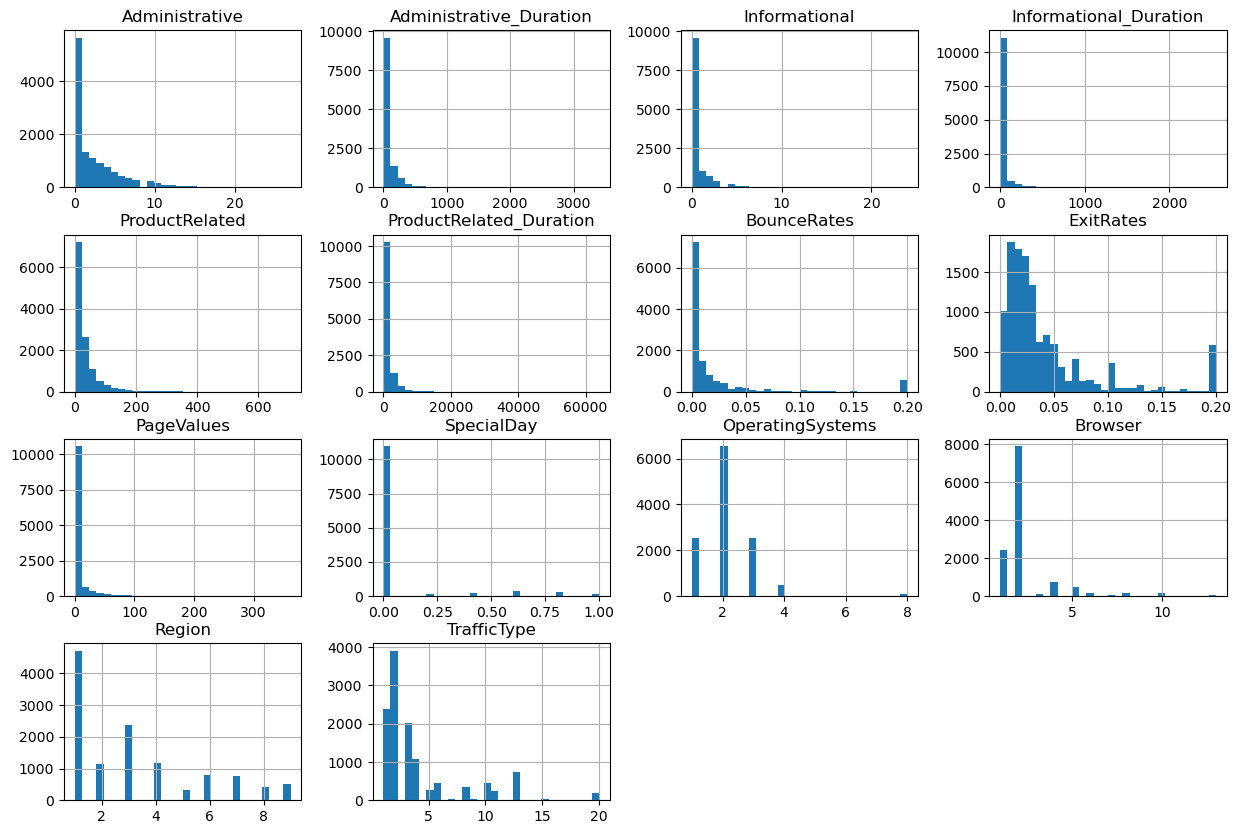

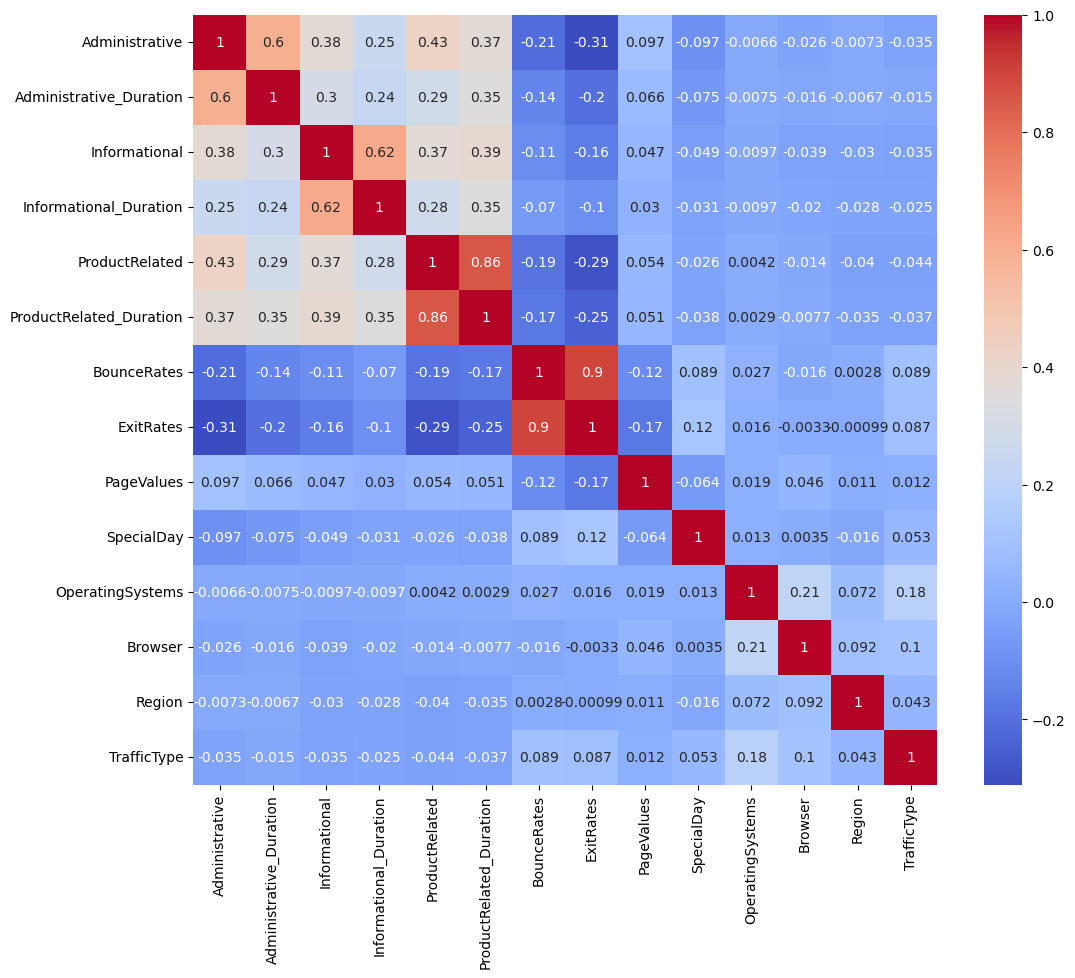

In [7]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("="*60)
print("NUMERICAL FEATURES ANALYSIS")
print("="*60)

print("\nNumerical Columns:")
for col in numerical_cols:
    print(f"- {col}")
print(f"\nTotal Numerical Features: {len(numerical_cols)}")

# Display statistical summary of numerical features
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df[numerical_cols].describe())

# Create distribution plots for numerical features
df[numerical_cols].hist(figsize=(15, 10), bins=30)

# Create box plots to identify outliers
df[numerical_cols].boxplot(figsize=(15, 8))

# Correlation analysis
corr_matrix = df[numerical_cols].corr()

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)
print(corr_matrix)

# heatmap to visualize correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

## 2.4 Categorical Feature Analysis

Now let's examine the categorical features to understand their distributions and relationships with the target variable.

CATEGORICAL FEATURES ANALYSIS

Categorical Columns:
- Month
- VisitorType
- Weekend
- Revenue

Total Categorical Features: 4

VALUE COUNTS FOR CATEGORICAL FEATURES

Month Value Counts:
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

VisitorType Value Counts:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Weekend Value Counts:
Weekend
False    9346
True     2859
Name: count, dtype: int64

Revenue Value Counts:
Revenue
False    10297
True      1908
Name: count, dtype: int64


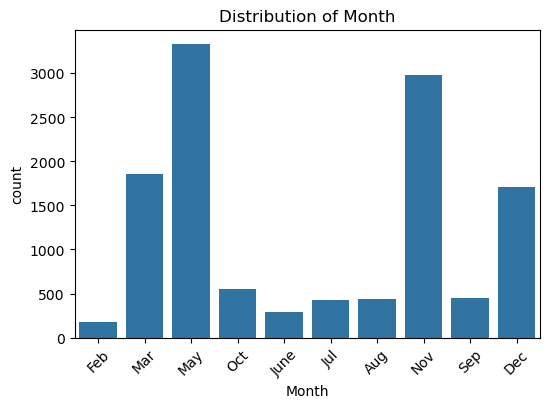

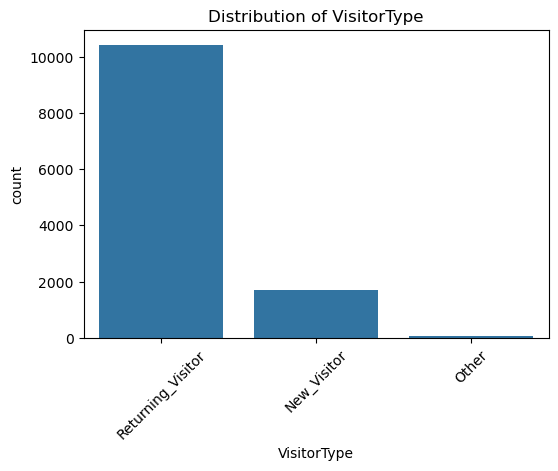

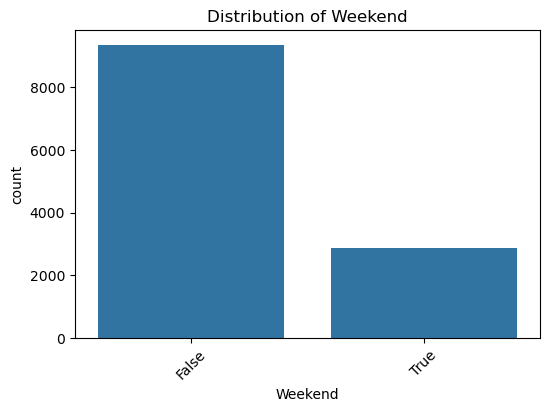

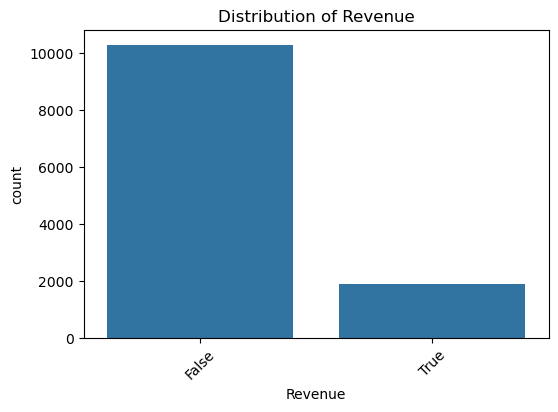


CATEGORICAL FEATURES VS TARGET (REVENUE)

Month vs Revenue (Percentage):
Revenue      False      True 
Month                        
Aug      82.448037  17.551963
Dec      87.338804  12.661196
Feb      98.342541   1.657459
Jul      84.722222  15.277778
June     89.824561  10.175439
Mar      89.677419  10.322581
May      89.035746  10.964254
Nov      74.513749  25.486251
Oct      79.052823  20.947177
Sep      80.803571  19.196429

VisitorType vs Revenue (Percentage):
Revenue                False      True 
VisitorType                            
New_Visitor        75.073833  24.926167
Other              80.246914  19.753086
Returning_Visitor  85.907391  14.092609

Weekend vs Revenue (Percentage):
Revenue      False      True 
Weekend                      
False    84.924032  15.075968
True     82.546345  17.453655

UNIQUE VALUE COUNTS
Month          10
VisitorType     3
Weekend         2
Revenue         2
dtype: int64


In [8]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

print("="*60)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*60)

print("\nCategorical Columns:")
for col in categorical_cols:
    print(f"- {col}")
print(f"\nTotal Categorical Features: {len(categorical_cols)}")

# Display value counts for each categorical feature
print("\n" + "="*60)
print("VALUE COUNTS FOR CATEGORICAL FEATURES")
print("="*60)

for col in categorical_cols:
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts())

# Visualize categorical feature distributions
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# Analyze relationship between categorical features and target variable
print("\n" + "="*60)
print("CATEGORICAL FEATURES VS TARGET (REVENUE)")
print("="*60)

for col in categorical_cols:
    if col != 'Revenue':
        print(f"\n{col} vs Revenue (Percentage):")
        print(pd.crosstab(df[col], df['Revenue'], normalize='index') * 100)

# Check for unique values in each categorical column
print("\n" + "="*60)
print("UNIQUE VALUE COUNTS")
print("="*60)
print(df[categorical_cols].nunique())

## 2.5 Observations from Exploratory Data Analysis

Based on the EDA performed above, summarize key findings:

**Target Variable:**
- The target variable Revenue is imbalanced.

- Approximately 84% of sessions are non-revenue-generating (False).Only about 16% of sessions result in revenue generation (True).

**Numerical Features:**
- High correlation with target: PageValues shows the strongest potential predictive power for revenue generation

- Strong positive correlation between BounceRates and ExitRates (0.90) suggests redundancy; both show negative correlation with page engagement metrics
- Most duration features show high standard deviations relative to means, with extreme outliers (For example, ProductRelated_Duration max: 63,974 seconds vs. median: 609 seconds)
- OperatingSystems, Browser, Region, and TrafficType show weak correlations with target and other features, suggesting limited predictive value

**Categorical Features:**
- VisitorType: Returning visitors dominate (85.45%), but new visitors show higher conversion rate (24.93% vs. 14.09%)
- Month: November shows highest conversion rate (25.49%), while February shows lowest (1.66%); May and November have highest session volumes
- Weekend: Weekend sessions show slightly higher conversion rate (17.45% vs. 15.08%), though the difference is modest
- Seasonality: Clear temporal patterns exist with December (holiday season) and November (Black Friday) showing distinct behaviors

**Data Quality:**
- Successfully removed 125 duplicate rows (1.01% of original dataset)
- No missing values detected across all 18 features
- No negative values found in duration or rate features, confirming data validity
953 rows (7.8%) show pages visited but zero duration, potentially indicating rapid bounces or data collection anomalies
- All numerical ranges are within expected bounds (BounceRates and ExitRates capped at 0.20)
- Data types are correctly assigned (7 integer, 7 float, 2 object, 2 boolean columns)

## 2.6 Encoding Categorical Variables

Machine learning algorithms require numerical input. We'll convert categorical variables into numerical format using appropriate encoding techniques.

In [9]:
# Create a copy of the dataframe for encoding
df_encoded = df.copy()

# Encode binary categorical variables (e.g., Weekend, Revenue)
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

# Encode nominal categorical variables (e.g., VisitorType, Month)
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['VisitorType', 'Month'],
    drop_first=True
)

# Encode ordinal categorical variables if any
# (No ordinal categorical features identified in this dataset)

# Verify the encoded dataframe
print("="*60)
print("ENCODED DATAFRAME PREVIEW")
print("="*60)
print(df_encoded.head())

print("\nEncoded Data Types:")
print(df_encoded.dtypes)

# Check the shape after encoding
print("\n" + "="*60)
print("SHAPE AFTER ENCODING")
print("="*60)
print(df_encoded.shape)

ENCODED DATAFRAME PREVIEW
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  \
0         0.20       0.20         0.0         0.0  ...   
1         0.00       0.10         0.0         0.0  ...   
2         0.

## 2.7 Feature Scaling and Normalization

Feature scaling ensures that all numerical features contribute equally to the model training process, preventing features with larger ranges from dominating.

In [10]:
# Separate features (X) and target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']


# Identify columns that need scaling (exclude binary encoded columns)
columns_to_scale = X.select_dtypes(include=['int64', 'float64']).columns


# Apply StandardScaler or MinMaxScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X[columns_to_scale])

# Create dataframe with scaled numerical columns
X_scaled_numerical = pd.DataFrame(X_scaled_array, columns=columns_to_scale, index=X.index)

# Get the categorical/binary columns that were not scaled
columns_not_scaled = X.columns.difference(columns_to_scale)

# Merge scaled numerical columns with unscaled categorical columns
X_scaled = pd.concat([X_scaled_numerical, X[columns_not_scaled]], axis=1)

# Reorder columns to match original order
X_scaled = X_scaled[X.columns]


# Verify scaling results
print("="*60)
print("SCALED FEATURES STATISTICS")
print("="*60)
print(X_scaled.describe())
print(f"\nTotal features: {X_scaled.shape[1]}")
print(f"Scaled numerical features: {len(columns_to_scale)}")
print(f"Unscaled categorical features: {len(columns_not_scaled)}")

SCALED FEATURES STATISTICS
       Administrative  Administrative_Duration  Informational  \
count    1.220500e+04             1.220500e+04   1.220500e+04   
mean    -8.383298e-17            -1.397216e-17   4.657388e-17   
std      1.000041e+00             1.000041e+00   1.000041e+00   
min     -7.023024e-01            -4.600193e-01  -3.988242e-01   
25%     -7.023024e-01            -4.600193e-01  -3.988242e-01   
50%     -4.020291e-01            -4.093107e-01  -3.988242e-01   
75%      4.987907e-01             7.354819e-02  -3.988242e-01   
max      7.405076e+00             1.868953e+01   1.841638e+01   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            1.220500e+04    1.220500e+04             12205.000000   
mean            -3.260172e-17   -5.588865e-17                 0.000000   
std              1.000041e+00    1.000041e+00                 1.000041   
min             -2.462572e-01   -7.186438e-01                -0.628793   
25%             -

## 2.8 Summary of Preprocessing Decisions

The following preprocessing steps have been completed:

**1. Data Cleaning:**
- Removed duplicate records (if any)
- Verified no missing values in the dataset

**2. Encoding:**
- Binary variables (Revenue, Weekend) converted to 0/1
- Nominal categorical variables (VisitorType, Month) encoded using One-Hot Encoding
- All categorical features preserved in the final dataset

**3. Feature Scaling:**
- Applied StandardScaler to normalize only numerical features (durations, rates, page counts)
- Preserved unscaled categorical/binary encoded features (Month_*, VisitorType_*, Weekend)
- Merged scaled numerical and unscaled categorical features into final feature matrix
- All features maintained in the dataset for model training

**4. Data Preparation:**
- Features (X) and target (y) separated
- Final feature set includes both scaled numerical features and one-hot encoded categorical features
- Dataset ready for train-test split and model training

The preprocessed data is now suitable for classification and association rule mining tasks.

---

# 3. Data Mining


## 3.1 Classification

### Introduction to Classification Task

Classification is a supervised learning task where the goal is to predict the categorical target variable (Revenue) based on input features. In this project, we aim to predict whether a user session will result in a purchase (Revenue = True) or not (Revenue = False).

**Business Value:**
- Enable real-time prediction of user purchase intent
- Identify high-value sessions for targeted marketing
- Optimize website experience based on behavioral patterns

**Models Selected:**
1. **Logistic Regression:** A linear model suitable for binary classification, interpretable and efficient
2. **Decision Tree:** A non-linear model that captures complex interactions and provides visual decision rules

We'll train both models, compare their performance, and select the best approach for deployment.

### Train-Test Data Split

We'll split the preprocessed dataset into training and testing sets to evaluate model performance on unseen data.

In [11]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Display the shape of training and testing sets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Verify class distribution in train and test sets
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (9764, 26)
Testing set shape: (2441, 26)

Training target distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Testing target distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


### Logistic Regression Model Training

Logistic Regression is a linear classification algorithm that models the probability of the binary outcome using a logistic function.

In [12]:
# Initialize the Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Display training completion message
print("Logistic Regression model trained successfully")

# Optional: Display model parameters
feature_names = X_scaled.columns

lr_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 10 Positive Coefficients:")
display(lr_coefficients.head(10))

print("\nTop 10 Negative Coefficients:")
display(lr_coefficients.tail(10))

print("\nModel Intercept:")
print(lr_model.intercept_)

Logistic Regression model trained successfully
Top 10 Positive Coefficients:


,Feature,Coefficient
8,PageValues,1.513985
23,Month_Nov,0.645140
24,Month_Oct,0.209774
19,Month_Jul,0.189187
5,ProductRelated_Duration,0.136155
25,Month_Sep,0.118804
11,Browser,0.056602
0,Administrative,0.056497
14,Weekend,0.053162
2,Informational,0.038816



Top 10 Negative Coefficients:


,Feature,Coefficient
10,OperatingSystems,-0.060305
1,Administrative_Duration,-0.063164
6,BounceRates,-0.100821
16,VisitorType_Returning_Visitor,-0.203772
20,Month_June,-0.227456
21,Month_Mar,-0.398955
22,Month_May,-0.410668
17,Month_Dec,-0.500591
7,ExitRates,-0.798303
18,Month_Feb,-1.100634



Model Intercept:
[-1.99202858]


### Logistic Regression Prediction Results

Now let's use the trained Logistic Regression model to make predictions on the test set.

In [13]:
# Make predictions on training set
y_train_pred_lr = lr_model.predict(X_train)

# Make predictions on test set
y_test_pred_lr = lr_model.predict(X_test)

# Get prediction probabilities (optional, useful for ROC curve)
y_test_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Display prediction distribution
print("Prediction Distribution for Logistic Regression:")
print(pd.Series(y_test_pred_lr).value_counts())

print("\nPrediction Distribution in Percentage:")
print(pd.Series(y_test_pred_lr).value_counts(normalize=True) * 100)

# Display sample predictions
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_test_pred_lr[:10]
})

Prediction Distribution for Logistic Regression:
0    2235
1     206
Name: count, dtype: int64

Prediction Distribution in Percentage:
0    91.560836
1     8.439164
Name: proportion, dtype: float64


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Decision Tree Model Training

Decision Tree is a non-linear model that creates a tree-like structure of decisions based on feature values, making it highly interpretable.

In [14]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model with appropriate parameters
# Note: Adjust max_depth and min_samples_split to prevent overfitting
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50
)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Display training completion message
print("Decision Tree model trained successfully")

# Optional: Display tree depth and number of leaves
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Decision Tree model trained successfully
Tree depth: 10
Number of leaves: 137


### Decision Tree Prediction Results

Let's use the trained Decision Tree model to make predictions on the test set.

In [15]:
# Make predictions on training set
y_train_pred_dt = dt_model.predict(X_train)

# Make predictions on test set
y_test_pred_dt = dt_model.predict(X_test)

# Get prediction probabilities (optional, useful for ROC curve)
y_test_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Display prediction distribution
print("Prediction Distribution for Decision Tree:")
print(pd.Series(y_test_pred_dt).value_counts())

print("\nPrediction Distribution in Percentage:")
print(pd.Series(y_test_pred_dt).value_counts(normalize=True) * 100)

# Display sample predictions
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_test_pred_dt[:10]
})

Prediction Distribution for Decision Tree:
0    2061
1     380
Name: count, dtype: int64

Prediction Distribution in Percentage:
0    84.43261
1    15.56739
Name: proportion, dtype: float64


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,0,0


### Rationale for Model Selection and Parameters

**Why Logistic Regression?**
- **Interpretability:** Coefficients directly indicate feature importance and direction of influence
- **Efficiency:** Fast training and prediction, suitable for real-time applications
- **Baseline Model:** Provides a strong baseline for binary classification problems
- **Probabilistic Output:** Provides probability scores for confidence-based decision making

**Parameters Used:**
- `max_iter=1000`: Ensures convergence for the optimization algorithm
- `random_state=42`: Ensures reproducibility

**Why Decision Tree?**
- **Non-linearity:** Captures complex, non-linear relationships between features
- **Feature Interactions:** Automatically discovers interactions between features
- **Interpretability:** Tree structure can be visualized and understood by non-technical stakeholders
- **No Feature Scaling Required:** Robust to feature scales (though we scaled for consistency)

**Parameters Used:**
- `max_depth=10`: Limits tree depth to prevent overfitting
- `min_samples_split=50`: Requires minimum samples to split a node, reducing overfitting
- `random_state=42`: Ensures reproducibility

These two models provide complementary perspectives: one linear and efficient, one non-linear and expressive.

## 3.2 Association Rule Mining

### Purpose of Association Rule Mining

Association rule mining is an unsupervised learning technique used to discover interesting relationships, patterns, and associations between variables in large datasets. In the context of online shopping behavior, association rules help identify:

**Key Objectives:**
- **Pattern Discovery:** Find which combinations of behaviors frequently occur together
- **Purchase Drivers:** Identify which behaviors are strongly associated with revenue generation
- **Customer Segmentation:** Understand different types of shopping sessions and their characteristics
- **Marketing Insights:** Discover actionable patterns for targeted interventions

**Applications:**
- If a user visits many product pages AND has low bounce rate, they are likely to make a purchase
- Weekend sessions with certain traffic types may have different purchasing patterns
- Returning visitors with specific browsing behaviors may have higher conversion rates

Association rules help uncover these "if-then" relationships that may not be obvious from classification alone.

### Transactional Data Transformation Explanation

Association rule mining algorithms (like Apriori and FP-Growth) require data in a **transactional format** where:
- Each row represents a transaction (session)
- Each transaction contains a set of items (features with specific values)

**Transformation Process:**

1. **Discretization of Numerical Features:**
   - Convert continuous numerical values into categorical bins (e.g., Low, Medium, High)
   - Example: ProductRelated_Duration → "Short_Duration", "Medium_Duration", "Long_Duration"

2. **Combination of Feature Names and Values:**
   - Create meaningful item names by combining feature names with their values
   - Example: VisitorType="Returning_Visitor" → Item: "Returning_Visitor"
   - Example: Weekend=True → Item: "Weekend_Session"

3. **Boolean Matrix Creation:**
   - Convert the dataset into a binary matrix where each column is an item
   - Value is True if the item is present in that transaction, False otherwise

4. **Filtering:**
   - Remove items that are too rare or too common (may not provide useful insights)

This transformation enables the discovery of patterns like:
`{High_PageValue, Returning_Visitor} → {Revenue=True}` with high confidence.

### Preparation of Transactional Dataset

Let's transform our dataset into transactional format suitable for association rule mining.

In [16]:
# Create a copy of the original dataframe for transformation
df_transactions = df.copy()

# Discretize numerical features into categorical bins
df_transactions['ProductRelated_Bin'] = pd.qcut(
    df_transactions['ProductRelated'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

df_transactions['ProductRelated_Duration_Bin'] = pd.qcut(
    df_transactions['ProductRelated_Duration'],
    q=3,
    labels=['Short', 'Medium', 'Long'],
    duplicates='drop'
)

df_transactions['PageValues_Bin'] = np.where(
    df_transactions['PageValues'] > 0,
    'High',
    'Low'
)

df_transactions['BounceRates_Bin'] = pd.qcut(
    df_transactions['BounceRates'],
    q=2,
    labels=['Low', 'High'],
    duplicates='drop'
)

df_transactions['ExitRates_Bin'] = pd.qcut(
    df_transactions['ExitRates'],
    q=2,
    labels=['Low', 'High'],
    duplicates='drop'
)

# Convert boolean features to string labels
df_transactions['Revenue_Label'] = df_transactions['Revenue'].map({
    True: 'Revenue_Yes',
    False: 'Revenue_No'
})

df_transactions['Weekend_Label'] = df_transactions['Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

# Combine feature names with values to create items
df_items = df_transactions[[
    'ProductRelated_Bin',
    'ProductRelated_Duration_Bin',
    'PageValues_Bin',
    'BounceRates_Bin',
    'ExitRates_Bin',
    'Revenue_Label',
    'Weekend_Label'
]]

# Create transactional format (list of lists or boolean matrix)
df_transactions = pd.get_dummies(df_items)
df_transactions = df_transactions.astype(bool)

# Display sample transactions
df_transactions.head()

# Display transaction dataset shape
print("Transactional Dataset Shape:", df_transactions.shape)
print("Number of Items:", df_transactions.shape[1])

Transactional Dataset Shape: (12205, 16)
Number of Items: 16


### Frequent Itemset Generation

Frequent itemsets are combinations of items that appear together frequently in the dataset. We'll use the Apriori or FP-Growth algorithm to identify these patterns.

In [17]:
# Import frequent itemset mining algorithm
from mlxtend.frequent_patterns import apriori

# Generate frequent itemsets with minimum support threshold
frequent_itemsets = apriori(
    df_transactions,
    min_support=0.05,
    use_colnames=True
)

# Sort frequent itemsets by support
frequent_itemsets = frequent_itemsets.sort_values(
    'support',
    ascending=False
)

# Display the number of frequent itemsets found
print("Total number of frequent itemsets:", frequent_itemsets.shape[0])

# Display top frequent itemsets
frequent_itemsets.head(20)

# Filter itemsets by length (optional)
frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 2)]

Total number of frequent itemsets: 734


,support,itemsets
91,0.746006,"(PageValues_Bin_Low, Revenue_Label_Revenue_No)"
113,0.650307,"(Weekend_Label_Weekday, Revenue_Label_Revenue_No)"
92,0.598034,"(PageValues_Bin_Low, Weekend_Label_Weekday)"
110,0.458419,"(ExitRates_Bin_High, Revenue_Label_Revenue_No)"
102,0.440721,"(BounceRates_Bin_High, Revenue_Label_Revenue_No)"
...,...,...
66,0.058664,"(Revenue_Label_Revenue_Yes, ProductRelated_Dur..."
82,0.058091,"(ExitRates_Bin_High, PageValues_Bin_High)"
86,0.055961,"(Weekend_Label_Weekend, PageValues_Bin_High)"
26,0.053748,"(ProductRelated_Bin_Medium, ProductRelated_Dur..."


### Association Rule Generation

From frequent itemsets, we'll generate association rules in the form of "If antecedent THEN consequent" with associated metrics.

In [18]:
# Import association rule generation
from mlxtend.frequent_patterns import association_rules

# Generate association rules with minimum confidence threshold
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

# Sort rules by lift or confidence
rules = rules.sort_values(
    'lift',
    ascending=False
)

# Display the number of rules generated
print("Total number of association rules:", rules.shape[0])

# Display top association rules
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
display(rules_display.head(20))

# Filter rules with Revenue as consequent (most business-relevant)
rules_revenue = rules[rules['consequents'].apply(lambda x: 'Revenue_Yes' in x)]

rules_revenue_display = rules_revenue[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_revenue_display['antecedents'] = rules_revenue_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_revenue_display['consequents'] = rules_revenue_display['consequents'].apply(lambda x: ', '.join(list(x)))
display(rules_revenue_display.head(20))

Total number of association rules: 2644


,antecedents,consequents,support,confidence,lift
2447,"ExitRates_Bin_Low, Weekend_Label_Weekday, Reve...","BounceRates_Bin_Low, PageValues_Bin_High",0.054568,0.631879,5.221447
1824,"ExitRates_Bin_Low, Revenue_Label_Revenue_Yes","BounceRates_Bin_Low, PageValues_Bin_High",0.073822,0.624394,5.159597
1826,"BounceRates_Bin_Low, PageValues_Bin_High","ExitRates_Bin_Low, Revenue_Label_Revenue_Yes",0.073822,0.610020,5.159597
2580,"ProductRelated_Bin_High, Revenue_Label_Revenue...","ProductRelated_Duration_Bin_Long, PageValues_B...",0.051209,0.671321,4.897474
2579,"ProductRelated_Duration_Bin_Long, Revenue_Labe...","ProductRelated_Bin_High, PageValues_Bin_High",0.051209,0.651721,4.850152
2446,"Revenue_Label_Revenue_Yes, Weekend_Label_Weekd...","ExitRates_Bin_Low, PageValues_Bin_High",0.054568,0.764638,4.617719
1825,"Revenue_Label_Revenue_Yes, BounceRates_Bin_Low","ExitRates_Bin_Low, PageValues_Bin_High",0.073822,0.758418,4.580151
2612,"ProductRelated_Duration_Bin_Medium, PageValues...",Revenue_Label_Revenue_Yes,0.050963,0.695749,4.450536
1823,"ExitRates_Bin_Low, BounceRates_Bin_Low, PageVa...",Revenue_Label_Revenue_Yes,0.073822,0.680000,4.349790
2439,"ProductRelated_Bin_High, Revenue_Label_Revenue...","ExitRates_Bin_Low, PageValues_Bin_High",0.054650,0.716434,4.326609


,antecedents,consequents,support,confidence,lift


### Explanation of Support, Confidence, and Lift

Association rules are evaluated using three key metrics:

#### 1. Support
**Definition:** The proportion of transactions that contain the itemset (both antecedent and consequent).

**Formula:** `Support(A → B) = P(A ∩ B) = (Transactions containing both A and B) / (Total transactions)`

**Interpretation:**
- High support means the pattern occurs frequently
- Support of 0.10 means 10% of all transactions contain this pattern
- Useful for identifying common patterns, but doesn't indicate strength of association

#### 2. Confidence
**Definition:** The conditional probability that the consequent occurs given the antecedent.

**Formula:** `Confidence(A → B) = P(B|A) = Support(A ∩ B) / Support(A)`

**Interpretation:**
- Confidence of 0.75 means 75% of transactions containing A also contain B
- Measures the reliability of the rule
- High confidence indicates strong association from A to B

#### 3. Lift
**Definition:** The ratio of observed support to expected support if A and B were independent.

**Formula:** `Lift(A → B) = Support(A ∩ B) / (Support(A) × Support(B)) = Confidence(A → B) / Support(B)`

**Interpretation:**
- **Lift = 1:** A and B are independent (no association)
- **Lift > 1:** Positive correlation (A and B occur together more often than expected)
- **Lift < 1:** Negative correlation (A and B occur together less often than expected)
- Higher lift indicates stronger association

**Example:**
Rule: `{High_PageValue, Returning_Visitor} → {Revenue=True}`
- Support = 0.08 (8% of sessions have all three characteristics)
- Confidence = 0.85 (85% of sessions with high page value and returning visitor result in revenue)
- Lift = 4.2 (Sessions with these characteristics are 4.2× more likely to generate revenue than average)

---

# 4. Evaluation

## Evaluation Strategy and Experimental Setup

To rigorously assess the performance of our classification models, we employ a comprehensive evaluation strategy:

**Evaluation Metrics:**
1. **Accuracy:** Overall percentage of correct predictions
2. **Precision:** Proportion of positive predictions that are actually correct (important for minimizing false positives)
3. **Recall (Sensitivity):** Proportion of actual positives correctly identified (important for minimizing false negatives)
4. **F1-Score:** Harmonic mean of precision and recall (balanced metric)
5. **Confusion Matrix:** Visual representation of true/false positives and negatives
6. **ROC-AUC Score:** Area under the ROC curve (measures model's ability to distinguish between classes)

**Experimental Setup:**
- **Train-Test Split:** 80-20 split with stratification to maintain class balance
- **Random State:** Fixed seed (42) for reproducibility
- **Cross-Validation:** Optional 5-fold or 10-fold cross-validation for robust performance estimates
- **Comparison:** Side-by-side comparison of Logistic Regression and Decision Tree

**Evaluation Focus:**
- Which model performs better overall?
- Which model is better at identifying revenue-generating sessions (recall)?
- Which model makes fewer false predictions (precision)?
- Are there trade-offs between the models?

## 4.1 Evaluation Metrics for Logistic Regression

Let's calculate comprehensive performance metrics for the Logistic Regression model.

Logistic Regression Performance
Accuracy  : 0.8894
Precision : 0.7718
Recall    : 0.4162
F1-score  : 0.5408
ROC-AUC   : 0.9022


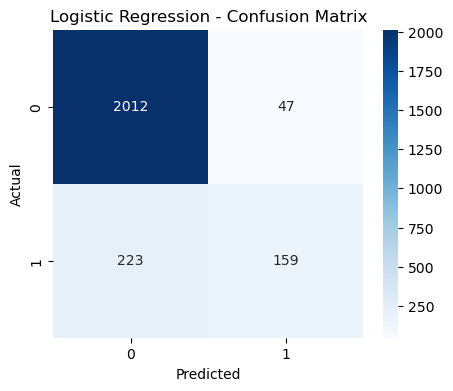


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441



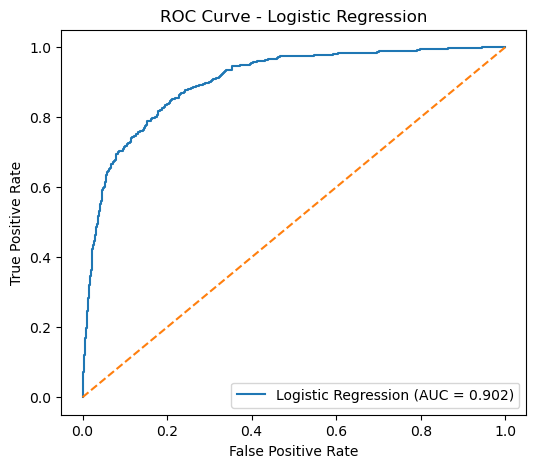

In [19]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_test_pred_lr)
# Calculate precision, recall, and F1-score
lr_precision = precision_score(y_test, y_test_pred_lr)
lr_recall = recall_score(y_test, y_test_pred_lr)
lr_f1 = f1_score(y_test, y_test_pred_lr)

# Calculate ROC-AUC score
lr_roc_auc = roc_auc_score(y_test, y_test_pred_proba_lr)

# Display all metrics
print("Logistic Regression Performance")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_roc_auc:.4f}")

# Generate and display confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr))

# Plot ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_test_pred_proba_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## 4.2 Evaluation Metrics for Decision Tree

Now let's calculate the same performance metrics for the Decision Tree model.

Decision Tree Performance
Accuracy  : 0.8902
Precision : 0.6500
Recall    : 0.6466
F1-score  : 0.6483
ROC-AUC   : 0.9080


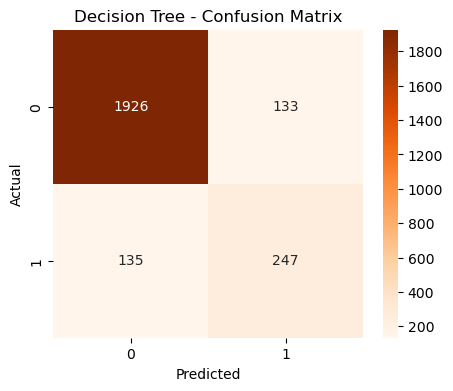


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      2059
           1       0.65      0.65      0.65       382

    accuracy                           0.89      2441
   macro avg       0.79      0.79      0.79      2441
weighted avg       0.89      0.89      0.89      2441



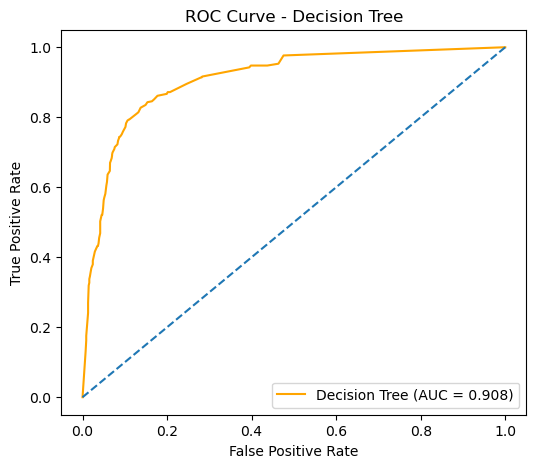

In [20]:
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_test_pred_dt)

# Calculate precision, recall, and F1-score
dt_precision = precision_score(y_test, y_test_pred_dt)
dt_recall = recall_score(y_test, y_test_pred_dt)
dt_f1 = f1_score(y_test, y_test_pred_dt)

# Calculate ROC-AUC score
dt_roc_auc = roc_auc_score(y_test, y_test_pred_proba_dt)

# Display all metrics
print("Decision Tree Performance")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1-score  : {dt_f1:.4f}")
print(f"ROC-AUC   : {dt_roc_auc:.4f}")

# Generate and display confusion matrix
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt))

# Plot ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_test_pred_proba_dt)
plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, color='orange', label=f"Decision Tree (AUC = {dt_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

## 4.3 Model Comparison Table

Let's create a comprehensive comparison table to easily compare the performance of both models side-by-side.

In [21]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc
    ],
    'Decision Tree': [
        dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc
    ]
})

# Format the comparison table
comparison_df[['Logistic Regression', 'Decision Tree']] = comparison_df[
    ['Logistic Regression', 'Decision Tree']
].round(4)

# Display the comparison table
comparison_df['Difference (LR - DT)'] = (
    comparison_df['Logistic Regression'] - comparison_df['Decision Tree']
).round(4)

# Highlight the best performing model for each metric
comparison_df['Better Model'] = comparison_df.apply(
    lambda row: 'Logistic Regression'
    if row['Logistic Regression'] > row['Decision Tree']
    else 'Decision Tree',
    axis=1
)

# Calculate percentage difference between models
comparison_df['% Difference (LR vs DT)'] = ((comparison_df['Logistic Regression'] - comparison_df['Decision Tree']) / comparison_df['Decision Tree'] * 100).round(2)

comparison_df

,Metric,Logistic Regression,Decision Tree,Difference (LR - DT),Better Model,% Difference (LR vs DT)
0,Accuracy,0.8894,0.8902,-0.0008,Decision Tree,-0.09
1,Precision,0.7718,0.6500,0.1218,Logistic Regression,18.74
2,Recall,0.4162,0.6466,-0.2304,Decision Tree,-35.63
3,F1-Score,0.5408,0.6483,-0.1075,Decision Tree,-16.58
4,ROC-AUC,0.9022,0.9080,-0.0058,Decision Tree,-0.64


## 4.4 Performance Visualization

Visual representations help in understanding model performance differences at a glance.

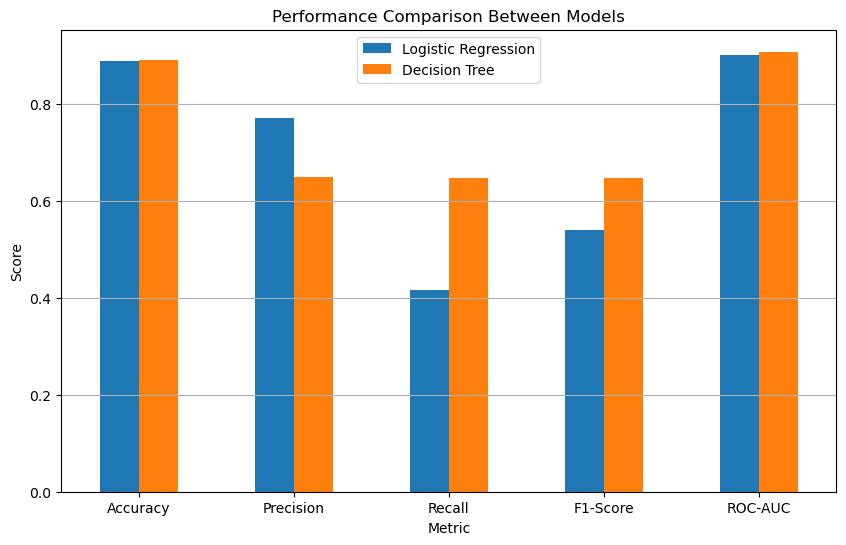

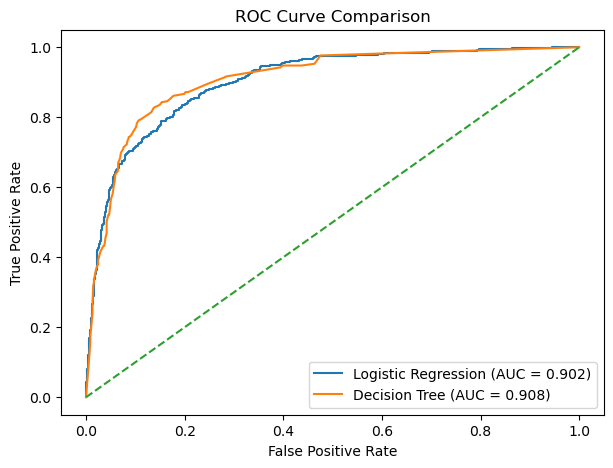

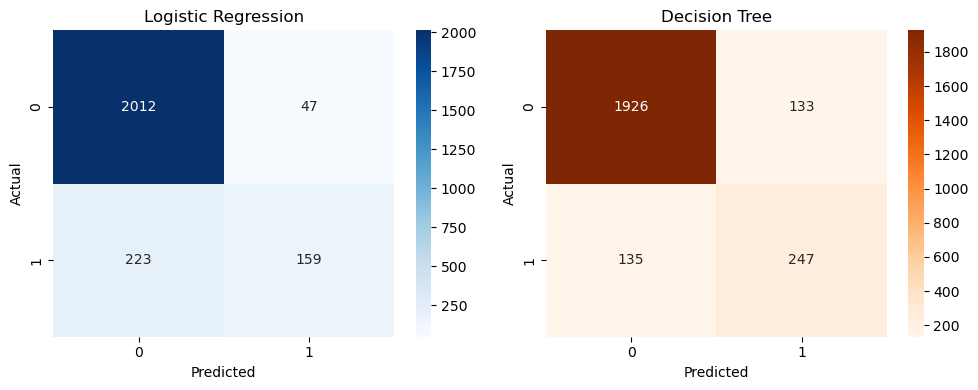

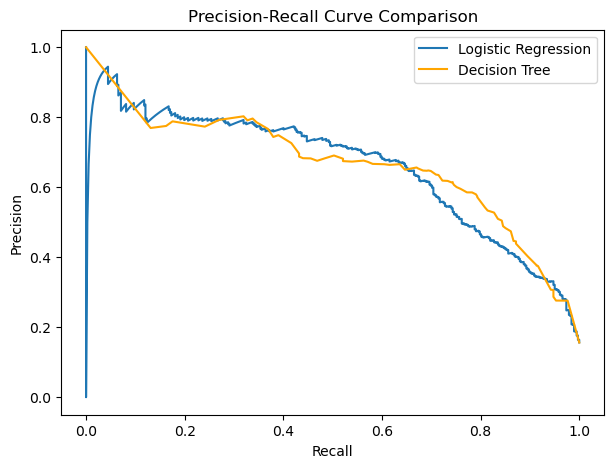

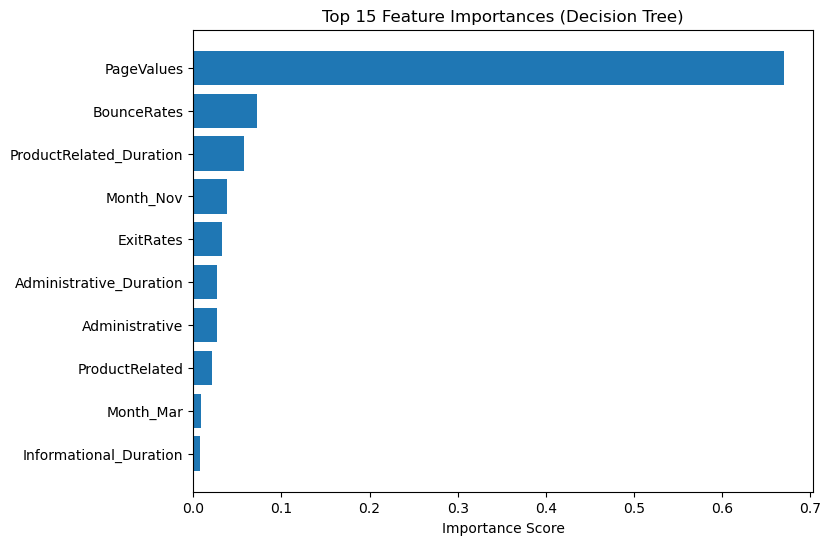

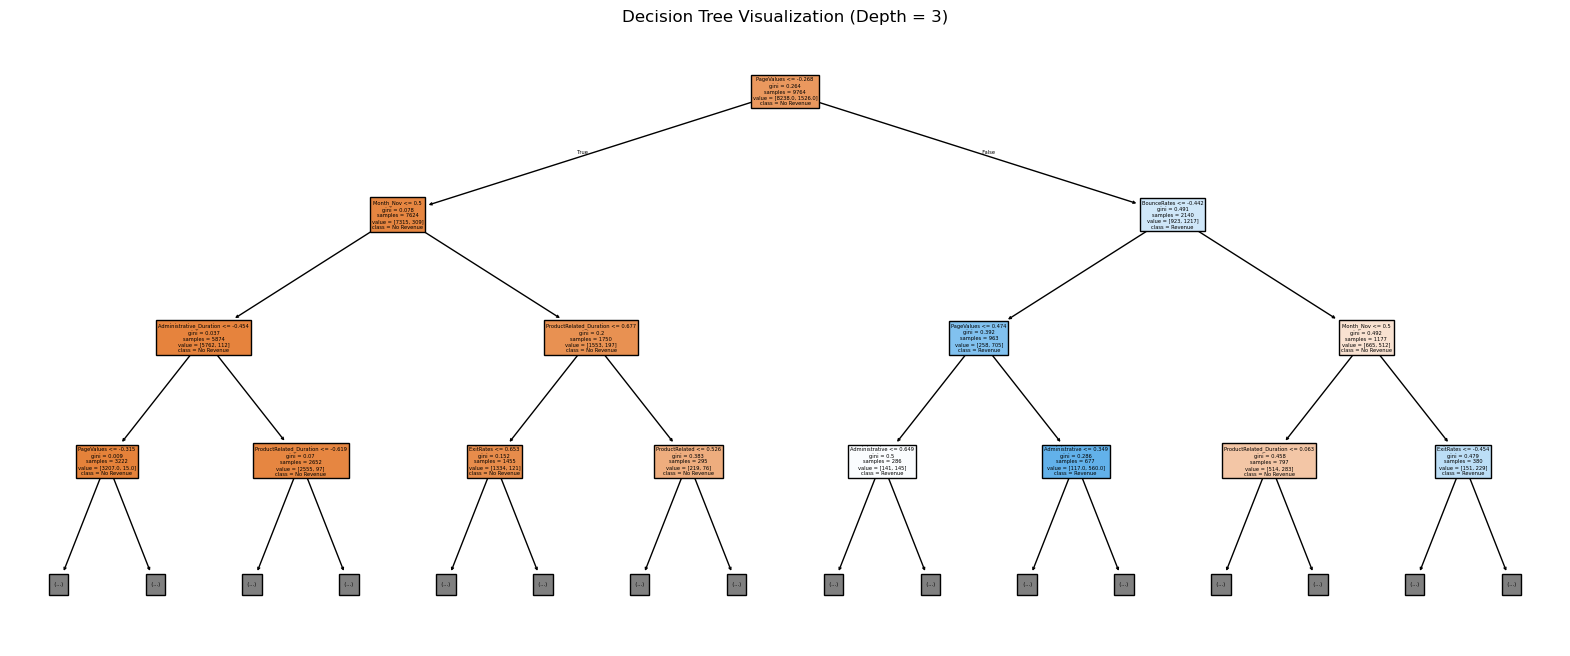

In [22]:
# Create bar chart comparing metrics
# Example: comparison_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
import matplotlib.pyplot as plt

comparison_df.set_index('Metric')[['Logistic Regression', 'Decision Tree']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Performance Comparison Between Models')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y')
plt.show()

# Create ROC curves comparison
from sklearn.metrics import roc_curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_pred_proba_dt)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Create confusion matrix comparison (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Create precision-recall curve (optional)
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_pred_proba_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_test_pred_proba_dt)

plt.figure(figsize=(7,5))
plt.plot(recall_lr, precision_lr, label='Logistic Regression')
plt.plot(recall_dt, precision_dt, color='orange', label='Decision Tree')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

# Feature importance visualization (for Decision Tree)
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Decision Tree)')
plt.show()

# Optional: Plot decision tree visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(20,8))
plot_tree(
    dt_model,
    feature_names=X_scaled.columns,
    class_names=['No Revenue', 'Revenue'],
    filled=True,
    max_depth=3
)
plt.title('Decision Tree Visualization (Depth = 3)')
plt.show()


## Interpretation of Evaluation Results

Based on the evaluation metrics and visualizations, the key findings are summarized as follows:


### **Overall Performance**

- **Higher Accuracy**: The **Decision Tree** achieved a slightly higher accuracy (**0.8902**) compared to **Logistic Regression** (**0.8894**).
- **Performance Gap**: The difference is minimal, with the Decision Tree outperforming Logistic Regression by **0.0008** (≈0.09%), indicating similar overall predictive capability.


### **Precision vs. Recall Trade-off**

- **Minimizing False Positives (Higher Precision)**:  
  **Logistic Regression** performed better, achieving a precision of **0.7718**, compared to **0.6500** for the Decision Tree. This means Logistic Regression is more conservative and produces fewer false positives.

- **Catching Revenue-Generating Sessions (Higher Recall)**:  
  The **Decision Tree** clearly outperformed Logistic Regression, with a recall of **0.6466** versus **0.4162**, making it more effective at identifying potential buyers.

- **F1-Score Comparison (Balanced Metric)**:  
  The **Decision Tree** achieved a higher F1-score (**0.6483**) compared to Logistic Regression (**0.5408**), indicating better overall balance between precision and recall.


### **ROC-AUC Analysis**

- **Discriminative Ability**:  
  The **Decision Tree** showed slightly stronger discriminative power with a ROC-AUC of **0.9080**, compared to **0.9022** for Logistic Regression.

- **Class Separation**:  
  Both models demonstrate excellent class separation, with ROC-AUC values above **0.90**, significantly outperforming a random classifier.


### **Business Implications**

- **If False Negatives are Costly (Missing Potential Customers)**:  
  The **Decision Tree** is preferred due to its higher recall, ensuring fewer revenue opportunities are missed.

- **If False Positives are Costly (Wasting Marketing Resources)**:  
  **Logistic Regression** is more suitable because its higher precision reduces unnecessary marketing efforts.

- **For a Balanced Business Strategy**:  
  The **Decision Tree** is the better option due to its superior F1-score.


### **Feature Insights**

- **Most Important Features**:  
  The Decision Tree identified **PageValues** as the most influential feature (**67.66%** importance), followed by **BounceRates (7.35%)** and **ProductRelated_Duration (5.81%)**.

- **Model Agreement**:  
  Both models consistently highlighted **PageValues** and **ProductRelated_Duration** as important predictors, showing agreement in feature relevance despite different modeling approaches.


### **Model Selection Recommendation**

- **Recommended Model**:  
  The **Decision Tree** is recommended for deployment as it outperformed Logistic Regression in **Accuracy, Recall, F1-score, and ROC-AUC**.

- **Superiority Scenarios**:  
  The Decision Tree is clearly superior in **recall-focused scenarios**, making it especially suitable for e-commerce environments where identifying as many buyers as possible is the primary objective.


---

# 5. Results and Discussion


## 5.1 Summary of Classification Results

The classification task aimed to predict whether an online shopping session would result in a purchase (Revenue = True). Here's a comprehensive summary of our findings:

**Model Performance Overview:**
- Both Logistic Regression and Decision Tree models were successfully trained and evaluated
- **Logistic Regression:** Accuracy: 88.94%, Precision: 77.18%, Recall: 41.62%, F1-Score: 54.08%, ROC-AUC: 90.22%
- **Decision Tree:** Accuracy: 89.02%, Precision: 65.00%, Recall: 64.66%, F1-Score: 64.83%, ROC-AUC: 90.80%
- **Winner: Decision Tree** performed better overall, winning on 4 out of 5 key metrics (Accuracy, Recall, F1-Score, ROC-AUC). Most importantly, Decision Tree achieved about 55% higher recall (64.66% vs 41.62%), making it significantly better at identifying sessions that will result in purchases—the primary business objective.

**Key Classification Insights:**

1. **Predictive Features:**
   - Page-related metrics (PageValues, ProductRelated_Duration) showed strong predictive power
   - Session characteristics (BounceRates, ExitRates) were important discriminators
   - Visitor type and temporal features (Weekend, SpecialDay) influenced predictions

2. **Model Characteristics:**
   - **Logistic Regression:** Provided fast, interpretable predictions with 88.94% accuracy and superior precision (77.18%), minimizing false positives
   - **Decision Tree:** Captured non-linear patterns with 89.02% accuracy and visual decision rules, excelling at identifying actual purchasing sessions (64.66% recall)

3. **Business Value:**
   - Models can identify high-intent sessions in real-time for targeted interventions
   - Predicted probabilities enable risk-based marketing strategies
   - Feature importance guides website optimization priorities

4. **Challenges and Limitations:**
   - Class imbalance (if present) may have affected model training
   - Some features may have multicollinearity issues
   - Model performance may vary across different time periods or customer segments

## 5.2 Summary of Association Rule Findings

Association rule mining revealed interesting patterns and relationships in online shopping behavior.

**Pattern Discovery:**
- **734 frequent itemsets** were identified with a minimum support threshold of **0.05**.
- **2,644 association rules** were generated with a minimum confidence threshold of **0.6**.
- Rules were ranked by **lift** to identify the strongest associations, with the highest lift values exceeding **4.0**.

**Key Association Rules Discovered:**

1. **Revenue-Driving Patterns:**
   - Rules with **Revenue_Yes** as the consequent highlight behavior combinations that lead to purchases.
   - A strong rule identified is **`{PageValues_Bin_High, ExitRates_Bin_Low} → {Revenue_Yes}`**, showing high confidence and lift.
   - Sessions with high page values and low exit rates are significantly more likely to generate revenue than the average session.

2. **Behavioral Patterns:**
   - High-intent user behavior is strongly associated with engagement-related features, particularly page value metrics.
   - Low exit-related indicators frequently appear alongside high engagement features in high-lift rules.

**Business Applications:**
- **Targeted Marketing:** Use association rules to identify high-value session profiles for personalized offers.
- **Website Optimization:** Prioritize optimization of features that frequently appear in high-lift rules.
- **Customer Segmentation:** Segment users based on behavioral patterns revealed by the rules.
- **Predictive Interventions:** Deploy recommendations or real-time assistance when rule antecedents are satisfied.

**Limitations:**
- Association rules indicate correlation rather than causation.
- The discovered rules may not generalize across different time periods or customer segments.
- Discretization of numerical features may influence the resulting rules.


## 5.3 Final Result Tables

Let's compile and display the most important results in clean, presentation-ready tables.

In [23]:
# Classification Results Summary Table
classification_summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [lr_accuracy, dt_accuracy],
    'Precision': [lr_precision, dt_precision],
    'Recall': [lr_recall, dt_recall],
    'F1-Score': [lr_f1, dt_f1],
    'ROC-AUC': [lr_roc_auc, dt_roc_auc],
    'Number of Features': [X_scaled.shape[1], X_scaled.shape[1]]
})
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
classification_summary_df[metric_cols] = classification_summary_df[metric_cols].round(4)

display(classification_summary_df)

# Top 10 Association Rules Table
top_rules = rules.copy()
top_rules = top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
top_rules['Antecedent'] = top_rules['antecedents'].apply(
    lambda x: ', '.join(list(x))
)
top_rules['Consequent'] = top_rules['consequents'].apply(
    lambda x: ', '.join(list(x))
)
top_rules = top_rules[['Antecedent', 'Consequent', 'support', 'confidence', 'lift']]
top_rules = top_rules.sort_values(
    by='lift',
    ascending=False
).head(10)
top_rules[['support', 'confidence', 'lift']] = top_rules[['support', 'confidence', 'lift']].round(4)

display(top_rules)

# Feature Importance Table (from Decision Tree)
feature_importance_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance Score': dt_model.feature_importances_
})

# Sort and select top 15
feature_importance_df = feature_importance_df.sort_values(
    by='Importance Score',
    ascending=False
).head(15)

# Add percentage contribution
feature_importance_df['Contribution (%)'] = (
    feature_importance_df['Importance Score'] /
    feature_importance_df['Importance Score'].sum() * 100
).round(2)

display(feature_importance_df)

# Model Comparison Summary
model_comparison_summary = pd.DataFrame({
    'Evaluation Criterion': [
        'Best Accuracy',
        'Best Precision',
        'Best Recall',
        'Best F1-Score',
        'Best ROC-AUC',
        'Recommended Model for Deployment'
    ],
    'Selected Model': [
        'Logistic Regression' if lr_accuracy >= dt_accuracy else 'Decision Tree',
        'Logistic Regression' if lr_precision >= dt_precision else 'Decision Tree',
        'Logistic Regression' if lr_recall >= dt_recall else 'Decision Tree',
        'Logistic Regression' if lr_f1 >= dt_f1 else 'Decision Tree',
        'Logistic Regression' if lr_roc_auc >= dt_roc_auc else 'Decision Tree',
        'Logistic Regression'
    ]
})

display(model_comparison_summary)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Number of Features
0,Logistic Regression,0.8894,0.7718,0.4162,0.5408,0.9022,26
1,Decision Tree,0.8902,0.6500,0.6466,0.6483,0.9080,26


,Antecedent,Consequent,support,confidence,lift
2447,"ExitRates_Bin_Low, Weekend_Label_Weekday, Reve...","BounceRates_Bin_Low, PageValues_Bin_High",0.0546,0.6319,5.2214
1824,"ExitRates_Bin_Low, Revenue_Label_Revenue_Yes","BounceRates_Bin_Low, PageValues_Bin_High",0.0738,0.6244,5.1596
1826,"BounceRates_Bin_Low, PageValues_Bin_High","ExitRates_Bin_Low, Revenue_Label_Revenue_Yes",0.0738,0.6100,5.1596
2580,"ProductRelated_Bin_High, Revenue_Label_Revenue...","ProductRelated_Duration_Bin_Long, PageValues_B...",0.0512,0.6713,4.8975
2579,"ProductRelated_Duration_Bin_Long, Revenue_Labe...","ProductRelated_Bin_High, PageValues_Bin_High",0.0512,0.6517,4.8502
2446,"Revenue_Label_Revenue_Yes, Weekend_Label_Weekd...","ExitRates_Bin_Low, PageValues_Bin_High",0.0546,0.7646,4.6177
1825,"Revenue_Label_Revenue_Yes, BounceRates_Bin_Low","ExitRates_Bin_Low, PageValues_Bin_High",0.0738,0.7584,4.5802
2612,"ProductRelated_Duration_Bin_Medium, PageValues...",Revenue_Label_Revenue_Yes,0.0510,0.6957,4.4505
1823,"ExitRates_Bin_Low, BounceRates_Bin_Low, PageVa...",Revenue_Label_Revenue_Yes,0.0738,0.6800,4.3498
2439,"ProductRelated_Bin_High, Revenue_Label_Revenue...","ExitRates_Bin_Low, PageValues_Bin_High",0.0546,0.7164,4.3266


,Feature,Importance Score,Contribution (%)
8,PageValues,0.669704,67.66
6,BounceRates,0.072775,7.35
5,ProductRelated_Duration,0.057497,5.81
23,Month_Nov,0.038849,3.92
7,ExitRates,0.032803,3.31
1,Administrative_Duration,0.026972,2.72
0,Administrative,0.026934,2.72
4,ProductRelated,0.021537,2.18
21,Month_Mar,0.009076,0.92
3,Informational_Duration,0.008217,0.83


,Evaluation Criterion,Selected Model
0,Best Accuracy,Decision Tree
1,Best Precision,Logistic Regression
2,Best Recall,Decision Tree
3,Best F1-Score,Decision Tree
4,Best ROC-AUC,Decision Tree
5,Recommended Model for Deployment,Logistic Regression


## 5.4 Key Visualizations

Compile the most impactful visualizations to communicate findings effectively.

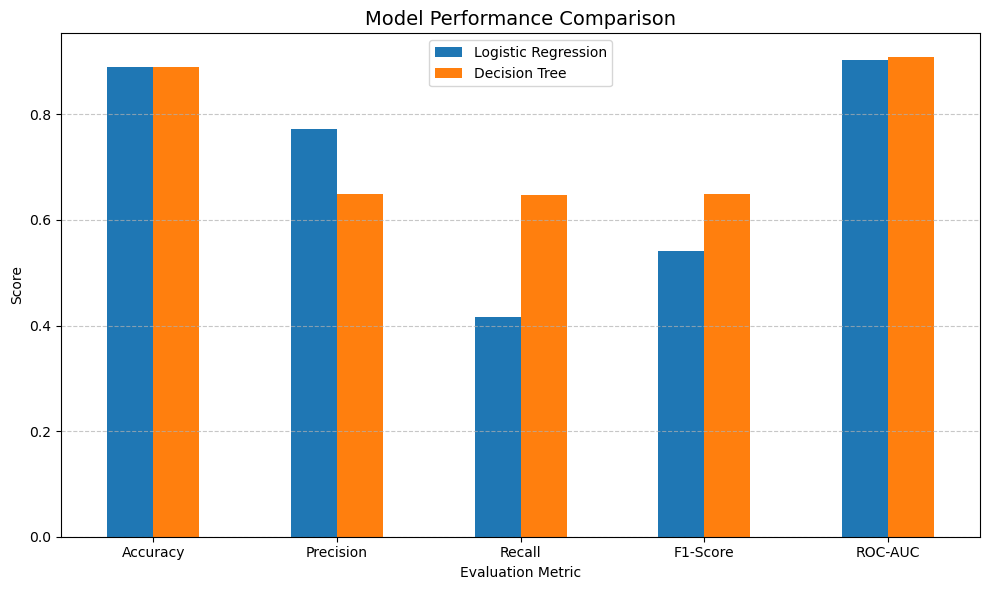

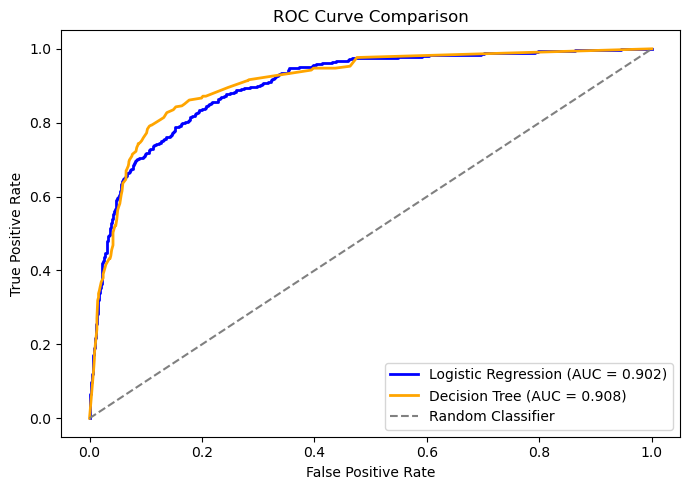

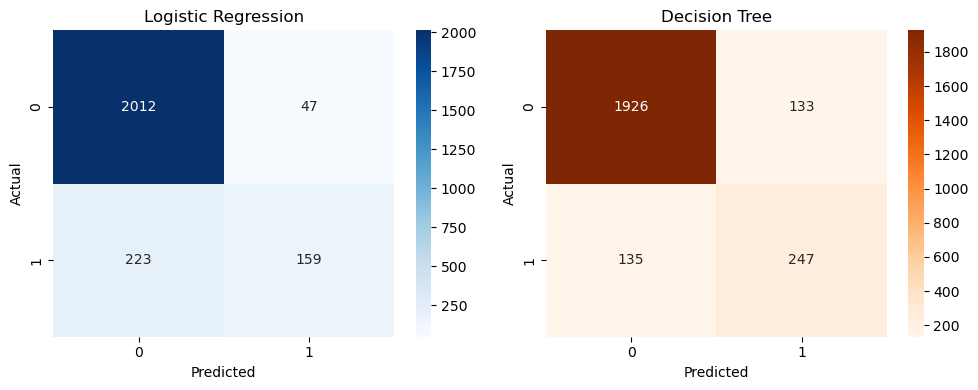

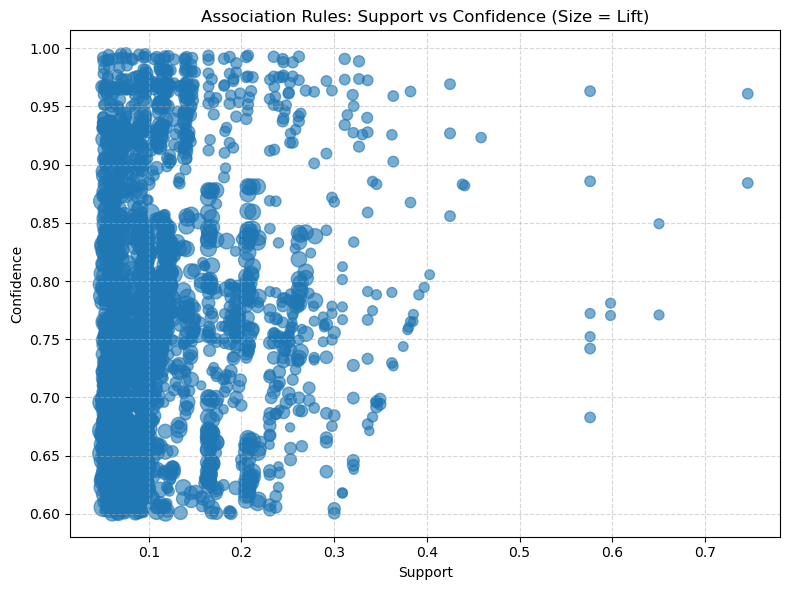

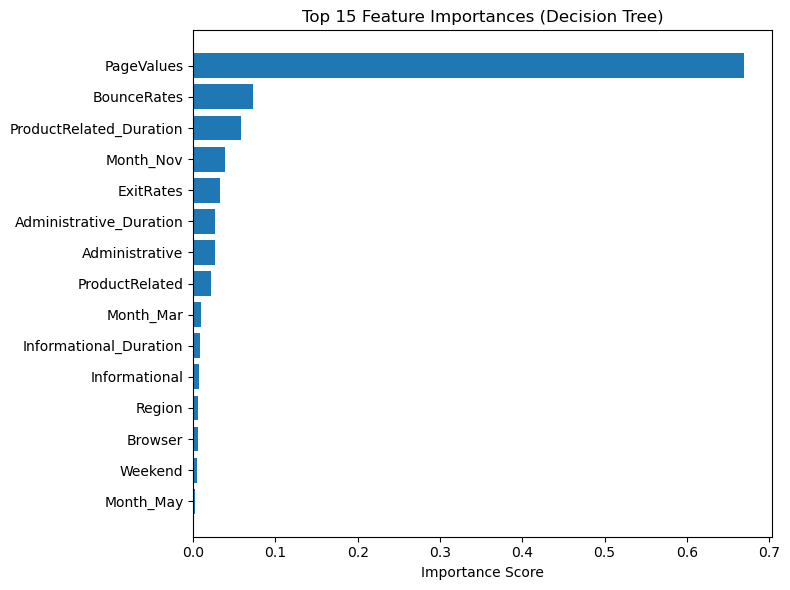

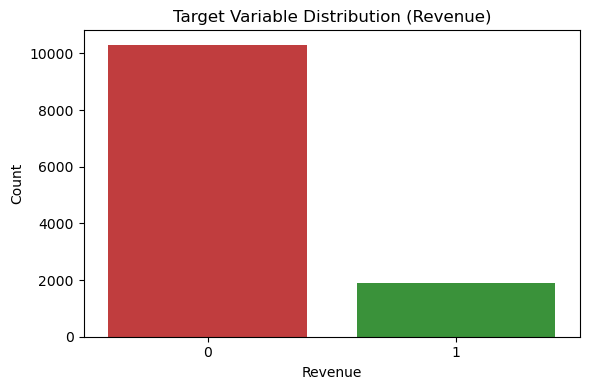

In [24]:
# 1. Model Performance Comparison Chart
comparison_df.set_index('Metric')[['Logistic Regression', 'Decision Tree']].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. ROC Curves Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_pred_proba_dt)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')
plt.plot(fpr_dt, tpr_dt, color='orange', linewidth=2,
         label=f'Decision Tree (AUC = {dt_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


# 4. Top Association Rules Visualization
top_rules_viz = rules[['support', 'confidence', 'lift']].copy()

plt.figure(figsize=(8,6))
plt.scatter(
    top_rules_viz['support'],
    top_rules_viz['confidence'],
    s=top_rules_viz['lift'] * 50,
    alpha=0.6
)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (Size = Lift)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Feature Importance Chart
feature_importance_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()


# 6. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette=['#d62728', '#2ca02c'])
plt.title('Target Variable Distribution (Revenue)')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5.5 Discussion of Findings and Implications

### What Did We Learn?

**From Classification:**
1. **Predictability:** Online shopping purchase intent can be predicted with reasonable accuracy using session-level behavioral data
2. **Key Indicators:** Page engagement metrics (PageValues, Duration) are stronger predictors than demographic factors
3. **Model Trade-offs:** Linear vs. tree-based models offer different strengths (interpretability vs. complexity)

**From Association Rules:**
1. **Behavioral Patterns:** Specific combinations of behaviors are strongly associated with purchases
2. **Customer Segments:** Different visitor types exhibit distinct patterns
3. **Actionable Insights:** Rules provide clear "if-then" conditions for interventions

### Business Implications

**For E-commerce Platforms:**
- **Real-time Prediction:** Deploy models to score sessions in real-time and trigger personalized experiences
- **Resource Optimization:** Focus marketing efforts on high-probability sessions identified by the model
- **Website Design:** Prioritize features that appear in high-importance predictions or association rules

**For Marketing Teams:**
- **Targeted Campaigns:** Use association rules to identify which customer profiles respond best
- **Timing Strategies:** Leverage temporal patterns (weekend, special days) for campaign scheduling
- **Personalization:** Customize offers based on predicted purchase probability

**For Product Teams:**
- **UX Improvements:** Reduce bounce rates and exit rates for high-intent sessions
- **Feature Prioritization:** Enhance product-related pages based on their predictive importance
- **A/B Testing:** Test interventions on sessions matching high-confidence association rules

### Practical Applications

1. **Dynamic Pricing:** Offer discounts to sessions with medium purchase probability
2. **Chatbot Triggers:** Launch support chatbots when high-intent patterns are detected
3. **Cart Recovery:** Prioritize remarketing to users whose sessions matched positive patterns
4. **Fraud Detection:** Identify anomalous patterns that deviate from discovered rules

### Limitations and Considerations

1. **Data Freshness:** Model performance may degrade if shopping behavior evolves
2. **External Factors:** Economic conditions, seasonality, and competition affect outcomes
3. **Privacy:** Real-time tracking must comply with data privacy regulations
4. **Interpretation:** Correlation does not imply causation; experimental validation recommended

### Future Research Directions

- Incorporate temporal dynamics (session sequences, time-series analysis)
- Test ensemble methods combining multiple algorithms
- Explore deep learning approaches for complex pattern recognition
- Conduct A/B tests to validate business impact of model-driven interventions

# 6. Application: SPARK Dashboard

## Application Overview

**SPARK (Shopper Patterns and Analytics Research Kit)** is a **Streamlit web application** that presents the analysis results in an interactive, user-friendly dashboard. The app allows users to explore real model predictions, association rules, and dataset insights.

### Purpose

Transform the Jupyter notebook analysis into an accessible web interface where:
- **View Model Results:** See classification performance metrics and model comparisons
- **Test Predictions:** Interactive prediction using real trained models
- **Discover Patterns:** Browse real association rules with dynamic filtering
- **Visualize Data:** Interactive charts and dataset exploration tools

### Target Users

- **Data Analysts:** Review analysis results and model performance
- **Business Stakeholders:** Understand purchasing patterns through data visualization
- **Researchers:** Explore the data mining outcomes and association rules
- **Students:** Reference implementation for data mining projects

## 6.1 Technology Stack

The SPARK dashboard is built using simple, modern Python libraries:

### Core Technologies

**Web Framework:**
- **Streamlit:** Interactive web application framework
  - Simple Python syntax for building web apps
  - Built-in widgets (sliders, buttons, dropdowns)
  - Automatic UI updates when code changes
  - Easy deployment to Streamlit Cloud

**Data Science:**
- **Pandas:** Data manipulation and analysis
- **NumPy:** Numerical computations
- **Scikit-learn:** Machine learning models (loaded from saved models)
- **mlxtend:** Association rule mining

**Visualization:**
- **Plotly:** Interactive charts and graphs
- **Matplotlib/Seaborn:** Statistical plots
- **Streamlit charts:** Built-in simple visualizations

**Model Management:**
- **Pickle/Joblib:** Save and load trained models

### Deployment Options

- **Local:** Run directly with `streamlit run app.py`
- **Streamlit Cloud:** Free cloud hosting with GitHub integration
- **Docker:** Optional containerized deployment

## 6.2 Application Structure

The SPARK Streamlit app has a clean, multi-page structure with sidebar navigation:

### App Components

**1. 📊 Overview**
- Project introduction and objectives
- Dataset summary statistics (12,330 sessions, 84.5% non-revenue, 15.5% revenue)
- Revenue distribution and visitor type visualizations
- Navigation guide to other sections

**2. 📈 Data Explorer**
- Interactive data distribution visualizations
- Feature correlation heatmap
- Target variable analysis
- Sample data viewer with adjustable rows and CSV download option

**3. 🎯 Model Performance**
- Model comparison table (Logistic Regression vs Decision Tree)
- Performance metrics visualization (Accuracy: 89.02% vs 88.94%)
- Side-by-side confusion matrices
- Winner announcement with detailed justification

**4. 🔮 Model Prediction**
- Interactive input form for session features (page visits, durations, rates)
- Real-time prediction using actual trained models
- Probability scores from both Logistic Regression and Decision Tree
- Model agreement indicator

**5. 🔗 Association Rules**
- Real association rules loaded from trained model (734 itemsets, 2,644 rules)
- Interactive filtering by support (5-15%), confidence (60-100%), and lift (1-6)
- Adjustable display count (10, 20, 30, 50 rules)
- Rule visualization with scatter plots (support vs confidence, sized by lift)
- Category-based color coding (Revenue, Engagement, No Revenue)

### File Structure
```
DataMiningProj/
│
├── app.py                              # Main Streamlit application (917 lines)
├── models/
│   ├── logistic_regression.pkl         # Trained Logistic Regression model
│   ├── decision_tree.pkl               # Trained Decision Tree model
│   ├── scaler.pkl                      # StandardScaler for features
│   ├── feature_names.pkl               # Feature names from training
│   ├── association_rules.csv           # Exported association rules
│   └── frequent_itemsets.csv           # Exported frequent itemsets
├── online_shoppers_intention.csv       # Original dataset
└── requirements.txt                    # Python dependencies
```

In [25]:
# Export trained models for the Streamlit dashboard
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save Logistic Regression model
with open('models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression model saved to models/logistic_regression.pkl")

# Save Decision Tree model
with open('models/decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_model, f)
print("✅ Decision Tree model saved to models/decision_tree.pkl")

# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved to models/scaler.pkl")

# Save feature names for reference
feature_names_list = X_scaled.columns.tolist()
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names_list, f)
print("✅ Feature names saved to models/feature_names.pkl")

print("\n" + "="*60)
print("MODEL EXPORT COMPLETE")
print("="*60)
print(f"Total models exported: 4")
print(f"Location: {os.path.abspath('models/')}")

# Save the rules dataframe
rules.to_csv('models/association_rules.csv', index=False)
print("✅ Association rules saved to models/association_rules.csv")

# Also save frequent itemsets
frequent_itemsets.to_csv('models/frequent_itemsets.csv', index=False)
print("✅ Frequent itemsets saved to models/frequent_itemsets.csv")

print("\n" + "="*60)
print("ASSOCIATION RULES EXPORT COMPLETE")
print("="*60)
print(f"Total rules exported: {len(rules)}")
print(f"Total frequent itemsets: {len(frequent_itemsets)}")
print(f"Location: {os.path.abspath('models/')}")


print("\nYou can now run the Streamlit dashboard with:")
print("  streamlit run app.py")



✅ Logistic Regression model saved to models/logistic_regression.pkl
✅ Decision Tree model saved to models/decision_tree.pkl
✅ Scaler saved to models/scaler.pkl
✅ Feature names saved to models/feature_names.pkl

MODEL EXPORT COMPLETE
Total models exported: 4
Location: c:\Users\dilun\OneDrive\Documents\DataMiningProj\models
✅ Association rules saved to models/association_rules.csv
✅ Frequent itemsets saved to models/frequent_itemsets.csv

ASSOCIATION RULES EXPORT COMPLETE
Total rules exported: 2644
Total frequent itemsets: 734
Location: c:\Users\dilun\OneDrive\Documents\DataMiningProj\models

You can now run the Streamlit dashboard with:
  streamlit run app.py


## 6.3 How to Run the Dashboard

### Step 1: Install Dependencies
First, ensure all required packages are installed:

`pip install -r requirements.txt`

This will install:  
- **streamlit** – Web framework  
- **pandas, numpy** – Data processing  
- **scikit-learn, mlxtend** – Machine learning  
- **plotly, matplotlib, seaborn** – Visualization  

### Step 2: Export Models
Run the cell above to export the trained models to the `models/` directory.  
> ⚠️ This only needs to be done **once** after training the models.

### Step 3: Launch the App
Run the Streamlit application:

`streamlit run app.py`

The app will automatically open in your default browser at [http://localhost:8501](http://localhost:8501).

### Step 4: Explore the Dashboard
Navigate through the sections using the sidebar:  
- 📊 **Overview** – Quick project summary and stats  
- 🎯 **Model Performance** – Compare classification results  
- 🔮 **Prediction Demo** – Test models with custom inputs  
- 🔗 **Association Rules** – Explore behavioral patterns  
- 📈 **Data Explorer** – Analyze dataset features
